# **Clinical Trial Success Prediction: Production Pipeline v01**

This notebook serves as the **Official Production Engine**. It builds the final predictive model used to feed the Streamlit application with XGBoost weights, Therapeutic Area-specific thresholds, and explainability artifacts.

### **Key Production Objectives:**
1. **Unified Dataset (2009–2022)**: Training on the full historical cohort to maximize contemporary signal.
2. **Recency-Weighted Calibration**: Optimizing decision boundaries with priority on recent trial outcomes.
3. **Full Explainability Export**: Generating SHAP values for the entire portfolio to support search and 'What-If' analysis.
4. **Artifact Persistence**: Saving the model, thresholds, and search data for the Streamlit app.

#### <REF:PROD_ENV_CONFIG>
> #### **1. Production Environment Configuration**

To ensure a seamless production workflow, we configure dynamic module reloading and precision-focused warning filters. This allows for iterative refinement of the `src` modules without requiring kernel restarts, while maintaining strict clinical data standards.

In [1]:
# --- AUTO-RELOAD MAGIC COMMANDS ---
%load_ext autoreload
%autoreload 2

import warnings
from tqdm.auto import tqdm
tqdm.pandas()

# Silence Warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

#### <REF:PROD_PATH_RESOLUTION>
> #### **2. Project Path Resolution and Dynamic Imports**

*   **Dynamic Root Detection:** Implements a filesystem traversal algorithm to locate the project root.
*   **Environment Path Augmentation:** Appends the root to `sys.path` to enable absolute imports from the `src` directory.
*   **Directory Standardization:** Defines global constants (`DATA_PATH`, `MODELS_PATH`) for consistent I/O operations.

In [2]:
import sys
from pathlib import Path

# 1. Define the Project Root
current_dir = Path.cwd()
project_root = current_dir

while not (project_root / 'src').exists():
    if project_root == project_root.parent:
        raise FileNotFoundError("Could not find project root containing 'src'")
    project_root = project_root.parent

# 2. Add Project Root to System Path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Define Key Paths
DATA_PATH = project_root / "data"
MODELS_PATH = project_root / "models"

print(f"Project Root: {project_root}")
print(f"Data Path:    {DATA_PATH}")
print(f"Models Path:  {MODELS_PATH}")

Project Root: /home/delaunan/code/delaunan/clintrialpredict
Data Path:    /home/delaunan/code/delaunan/clintrialpredict/data
Models Path:  /home/delaunan/code/delaunan/clintrialpredict/models


#### <REF:PROD_LIB_INIT>
> #### **3. Library and Custom Module Initialization**

Initializes foundational analytical libraries (`pandas`, `numpy`) and domain-specific engines:
*   **ClinicalTrialLoader:** Orchestrates raw data ingestion and feature engineering.
*   **Preprocessor:** Factory for the `ColumnTransformer` pipeline, handling scaling, encoding, and PCA-based NLP text compression.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

# Custom Modules
from src.prep.data_loader import ClinicalTrialLoader
from src.prep.preprocessing import preprocessor

#### <REF:PROD_DATA_PIPELINE>
> #### **4. Unified Data Pipeline (2009–2022)**

The pipeline executes a multi-stage ETL process to generate the analytical cohort. It strictly filters for trials within the 2009-2022 window with confirmed binary outcomes, prioritizing the pre-processed `project_data.csv` feature store for longitudinal consistency.

In [4]:
# --- PRODUCTION WINDOW DEFINITION ---
import os
from dotenv import load_dotenv
load_dotenv()

PROD_START_YEAR = int(os.getenv('PROD_START_YEAR', 2009))
PROD_END_YEAR = int(os.getenv('PROD_END_YEAR', 2022))

# --- DATA LOADING & FEATURE STORE CHECK ---
PROJECT_DATA_PATH = DATA_PATH / "project_data.csv"

if PROJECT_DATA_PATH.exists():
    df = pd.read_csv(PROJECT_DATA_PATH, low_memory=False)
    print(f">>> Loaded existing project_data.csv | Shape: {df.shape}")
else:
    print(">>> project_data.csv not found. Initializing full ingestion pipeline...")
    # Note: Using data_loader_clinpred logic if needed, but production_04 
    # typically relies on the consolidated 'project_data.csv' or the new loader.
    from src.prep.data_loader_clinpred import ClinicalTrialLoader
    loader = ClinicalTrialLoader(str(DATA_PATH))
    df = loader.load_base_data()
    df = loader.add_features(df)
    loader.check_and_export_nlp(df)

# --- PRODUCTION FILTERING ---
print(f">>> Applying Production Window: {PROD_START_YEAR} to {PROD_END_YEAR}...")
df = df[df['start_year'].between(PROD_START_YEAR, PROD_END_YEAR)].copy()

# Ensure target is strictly valid (Known outcomes only)
df = df.dropna(subset=['target']).copy()
df['target'] = df['target'].astype(int)
print(f">>> Final Production Cohort: {df.shape[0]:,} trials")


>>> project_data.csv not found. Initializing full ingestion pipeline...
>>> 1. Loading Studies & Applying Filters...
    [Filter] Kept 126474 Industry-led trials.
    [Sanitizer] Dropping 169 trials terminated due to COVID/Logistics.
    Core Cohort: 34155 trials (Phase 1/2/3, 2005-2025 training window and 2005-2025 for production).
>>> 2. Engineering Features...
    -> Grouping Phases into Efficacy Tiers...
    -> Engineering Clinical Setting (Deep Search & Composite)...
    -> Engineering Comparator Architecture (Robust)...
    -> Engineering Protocol Duration (Waterfall)...
    -> Engineering Sponsor Tiers...
    -> Engineering Protocol Complexity (Calculating Age Flags)...
    -> Attaching Medical Hierarchy (Vectorized Optimization)...
       Applying Vectorized Regex (High Speed)...
       Running Final Title Scan on 4576 unclassified trials (Vectorized)...
    -> Hierarchy Attachment Complete.
    -> Adding UI-friendly text fields (latest text only)...
    -> Engineering NLP Text

#### <REF:PROD_DATA_AUDIT>
> #### **5. Forensic Data Audit: Production Cohort Integrity**

Before training, we execute a forensic audit to verify dataset completeness. This phase ensures critical columns (`start_year`, `target`, `therapeutic_area`) are present and that NLP embedding dimensions contain non-zero signal, safeguarding against data corruption.

In [5]:
def audit_production_data(df):
    print("="*80)
    print("PRODUCTION DATA AUDIT")
    print("="*80)

    # Check for Critical Columns
    critical = ['start_year', 'target', 'therapeutic_area']
    for col in critical:
        status = "[PASS]" if col in df.columns else "[FAIL]"
        print(f"{status} {col:<20}")

    # Embedding Presence
    # Count all NLP pillars (crit_, sci_, endp_)
    emb_cols = [c for c in df.columns if c.startswith(('crit_', 'sci_', 'endp_'))]
    if len(emb_cols) > 0:
        print(f"[INFO] Detected {len(emb_cols)} NLP dimensions.")
        # Check signal in the first dimension of each pillar
        pillars = ['crit_0', 'sci_0', 'endp_0']
        all_passed = True
        for p in pillars:
            if p in df.columns:
                if df[p].sum() == 0:
                    all_passed = False
                    print(f"[FAIL] Embedding pillar {p} contains no signal.")

        if all_passed:
            print("[PASS] Embeddings contain non-zero signal.")
    else:
        print("[WARN] No Embeddings found. Ensure NLP vectors are attached.")

audit_production_data(df)


PRODUCTION DATA AUDIT
[PASS] start_year          
[PASS] target              
[PASS] therapeutic_area    
[INFO] Detected 2304 NLP dimensions.
[PASS] Embeddings contain non-zero signal.


#### <REF:PROD_MODEL_FIT>
> #### **6. Production Model Configuration: XGBoost**

We train the engine using XGBoost with high regularization (`reg_alpha=30`, `reg_lambda=30`) to ensure generalization. The `scale_pos_weight` is dynamically calculated to prioritize failure-class signals, anchored to the modern failure rate (31.1%).

In [6]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

print('>>> Preparing Production Training Matrix...')

cols_meta = ['target', 'nct_id', 'start_date', 'start_year', 'official_title', 'why_stopped']
cols_text = [c for c in df.columns if c.startswith('txt_')]
cols_raw  = [c for c in df.columns if c.startswith('raw_')]
cols_ui   = [c for c in df.columns if c.startswith('ui_')]
cols_extra = ['Clinical_Score', 'Zone', 'prediction_quality', 'trial_segment', 'agency_class']
cols_to_drop = cols_meta + cols_text + cols_raw + cols_ui + cols_extra

X_train = df.drop(columns=cols_to_drop, errors='ignore')
y_train = df['target']

n_pos = y_train.sum()
ratio = (len(y_train) - n_pos) / n_pos

xgb = XGBClassifier(
    n_estimators=495, learning_rate=0.02, max_depth=3,
    min_child_weight=25, gamma=10, subsample=0.728,
    colsample_bytree=0.30, reg_alpha=30, reg_lambda=30,
    scale_pos_weight=ratio, tree_method='hist', eval_metric='logloss',
    n_jobs=-1, random_state=42, enable_categorical=False
)

model = Pipeline([('prep', preprocessor()), ('clf', xgb)])

print(f'>>> Fitting Production Pipeline on {X_train.shape[0]:,} trials...')
model.fit(X_train, y_train)

# BUG FIX: Enable unique feature names for PCA components in SHAP
model.named_steps['prep'].verbose_feature_names_out = True

print('    [DONE] Model 01 training complete.')

>>> Preparing Production Training Matrix...
>>> Fitting Production Pipeline on 24,592 trials...
    [DONE] Model 01 training complete.


#### <REF:PROD_DYN_THRESH>
> #### **7. Recency-Weighted Calibration: Strategy & Optimization**

**Testing Strategy:** We implement a linear recency weighting (0.1 anchor at 2009 to 1.0 at 2022). This forces decision boundaries to align with modern failure patterns. We optimize for the F-beta score (beta=1.15) to favor precision in failure detection.

In [7]:
from sklearn.metrics import precision_recall_curve
from scipy.special import logit

def find_optimal_threshold(y_true, y_probs, beta=1.15, weights=None):
    p, r, t = precision_recall_curve(y_true, y_probs, sample_weight=weights)
    f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-9)
    return t[np.argmax(f[:-1])] if len(t) > 0 else 0.5

print('>>> Starting Production Calibration (2009-2022)...')

# 1. Recency Weighting
y_prob_train = model.predict_proba(X_train)[:, 1]
train_years = df.loc[X_train.index, 'start_year']
y_min, y_max = train_years.min(), train_years.max()
w_floor, w_ceil = 0.1, 1.0
train_weights = w_floor + (w_ceil - w_floor) * (train_years - y_min) / (y_max - y_min)

df_cal = pd.DataFrame({
    'TA': X_train['therapeutic_area'],
    'true': y_train.values,
    'prob': y_prob_train,
    'weight': train_weights
})

# 2. Threshold Optimization
global_thresh = find_optimal_threshold(df_cal['true'], df_cal['prob'], weights=df_cal['weight'])
global_logit = float(logit(np.clip(global_thresh, 1e-5, 1-1e-5)))

final_thresholds = {}
final_threshold_logits = {}
min_samples_policy = 500

ta_counts = df_cal['TA'].value_counts()
for ta, count in ta_counts.items():
    df_ta = df_cal[df_cal['TA'] == ta]
    if count < min_samples_policy or df_ta['true'].nunique() <= 1:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
    else:
        t_ta = find_optimal_threshold(df_ta['true'], df_ta['prob'], weights=df_ta['weight'])
        final_thresholds[ta] = t_ta
        final_threshold_logits[ta] = float(logit(np.clip(t_ta, 1e-5, 1-1e-5)))

print(f"🌍 Global Threshold: {global_thresh:.4f} | Calibrated {len(final_thresholds)} TAs.")

>>> Starting Production Calibration (2009-2022)...
🌍 Global Threshold: 0.4990 | Calibrated 24 TAs.


#### <REF:PROD_EXPLAIN_ENGINE>
> #### **8. Explainability Engine: Portfolio-Wide SHAP Decomposition**

To support the 'What-If' features, we calculate SHAP values for the entire portfolio. This translates complex model logits into human-readable success and risk drivers, pre-computed for zero-latency search performance.

In [8]:
import shap

print('>>> Initializing SHAP TreeExplainer...')
prep_step = model.named_steps['prep']
X_trans = prep_step.transform(X_train)
feature_names = prep_step.get_feature_names_out()

explainer = shap.TreeExplainer(model.named_steps['clf'])
print('>>> Calculating SHAP values for all trials (this may take a few minutes)...')
shap_values = explainer.shap_values(X_trans)

model_base_value = explainer.expected_value
if isinstance(model_base_value, (list, np.ndarray)):
    model_base_value = model_base_value[0]

print(f"    [DONE] Matrix Shape: {shap_values.shape} | Intercept: {model_base_value:.4f}")

>>> Initializing SHAP TreeExplainer...
>>> Calculating SHAP values for all trials (this may take a few minutes)...
    [DONE] Matrix Shape: (24592, 548) | Intercept: 0.0169


#### <REF:PROD_SCORE_ENGINE>
> #### **9. Clinical Success Scoring Engine: The 0–100 Transformation**

Translates raw log-odds and SHAP attributions into the **Clinical Success Score**. 
*   **Score 50.0:** Represents the calibrated decision boundary for each specific Therapeutic Area.
*   **Calibration Offset:** Mathematically merged into the *Therapeutic Context* pillar for 100% visualization consistency.

In [9]:
# <REF:PROD_SCORE_ENGINE_CODE>
RISK_TAXONOMY = {
    "1. Therapeutic Context": {
        "Indication Risk Profile": {
            "features": [
                "cat_onehot__therapeutic_area_",
                "cat_target__therapeutic_subgroup_name",
                "CALIBRATION_OFFSET"
            ],
            "feature_labels": [
                "Net Disease Risk"
            ],
            "logic": "The combined risk profile of the therapeutic area and specific indication, adjusted for sector difficulty.",
            "pos_impact": "Therapeutic area and indication show a rather favorable risk profile based on historical evidence.",
            "neg_impact": "Therapeutic area and indication may correspond to elevated challenge levels given past records."
        },
        "Development Phase": {
            "features": [
                "cat_onehot__phase_PHASE",
                "cat_onehot__phase_group_"
            ],
            "feature_labels": [
                "Trial Phase",
                "Phase Tier"
            ],
            "logic": "The statistical probability of success (POS) based on development stage.",
            "pos_impact": "The current study stage is statistically associated with higher completion rates.",
            "neg_impact": "The current study stage is associated with higher attrition risks."
        }
    },
    "2. Scientific Design": {
        "Scientific Rationale": {
            "features": [
                "pca_sci"
            ],
            "feature_labels": [
                "Scientific Text Analysis"
            ],
            "logic": "Text analysis of the Title and Brief Summary for novelty and clarity.",
            "pos_impact": "Text analysis suggests the scientific rationale is clear, focused, and aligns with successful precedents.",
            "neg_impact": "Text analysis suggests the scientific description may be ambiguous, with lesser focus or highly novel, which tends to carry higher uncertainty."
        },
        "Endpoint Strategy": {
            "features": [
                "pca_endp"
            ],
            "feature_labels": [
                "Endpoint Text Analysis"
            ],
            "logic": "Text analysis of the Primary Endpoints for measurability.",
            "pos_impact": "Primary endpoints appear well-defined and measurable, consistent with previous successful trials.",
            "neg_impact": "Endpoints can be improved as they may appear complex or subjective, which tends to introduce measurement variability."
        },
        "Trial Complexity": {
            "features": [
                "num_log__number_of_arms",
                "cat_onehot__primary_purpose_"
            ],
            "feature_labels": [
                "Arm Count",
                "Primary Purpose"
            ],
            "logic": "Structural design of the study arms.",
            "pos_impact": "The structural design (number of arms and primary purpose) suggests a comprehensive comparative strategy.",
            "neg_impact": "The structural design (number of arms and primary purpose) suggests either a simplified exploratory focus or a level of complexity that may increase operational burden,"
        }
    },
    "3. Execution Framework": {
        "Quality & Bias Control": {
            "features": [
                "bin_flags__has_dmc",
                "num_std__design_rigor_score",
                "cat_onehot__masking_"
            ],
            "feature_labels": [
                "Data Monitoring Comm.",
                "Rigor Score",
                "Blinding"
            ],
            "logic": "Operational mechanisms implemented to minimize bias and ensure safety oversight.",
            "pos_impact": "Operational controls (e.g., DMC, masking) are in place to safeguard data integrity and reduce bias.",
            "neg_impact": "The protocol suggests limited bias mitigation or oversight mechanisms, increasing operational vulnerability."
        },
        "Time Horizon": {
            "features": [
                "num_log__duration_months"
            ],
            "feature_labels": [
                "Estimated Duration"
            ],
            "logic": "The operational exposure time of the study.",
            "pos_impact": "Shorter duration tends to minimize exposure to long-term operational risks.",
            "neg_impact": "Extended timeline tends to increase the risk of participant dropout and resource exhaustion."
        },
        "Sponsor Profile": {
            "features": [
                "cat_onehot__sponsor_tier_"
            ],
            "feature_labels": [
                "Sponsor Tier"
            ],
            "logic": "The track record and financial depth of the sponsor.",
            "pos_impact": "Sponsor profile suggests established resources, experience or operational resilience.",
            "neg_impact": "Sponsor profile may be sensitive to funding constraints or prone to frequent strategic portfolio shifts."
        }
    },
    "4. Patient Profile": {
        "Inclusion Criteria": {
            "features": [
                "pca_crit",
                "num_std__criteria_len_log",
                "num_std__eligibility_strictness_score"
            ],
            "feature_labels": [
                "Criteria Text Analysis",
                "Criteria Length",
                "Strictness Score"
            ],
            "logic": "Text analysis of the eligibility rules.",
            "pos_impact": "Eligibility criteria appear concise and balanced, facilitating smoother enrollment.",
            "neg_impact": "Lengthy or highly restrictive criteria tend to create enrollment bottlenecks."
        },
        "Patient Acuity": {
            "features": [
                "bin_flags__is_sick_only",
                "bin_flags__is_severe",
                "bin_flags__is_acute",
                "bin_flags__is_refractory",
                "bin_flags__is_critical_setting"
            ],
            "feature_labels": [
                "Healthy vs Patient",
                "Severe Disease",
                "Acute Setting",
                "Refractory Status",
                "Critical Setting Flag"
            ],
            "logic": "The health status of the target population.",
            "pos_impact": "Target population appears stable, potentially reducing unexpected medical complications.",
            "neg_impact": "Populations with high disease severity, acuity, or refractory status tend to be associated with elevated operational risks."
        }
    }
}

GAIN_FACTOR = 25.0

def generate_production_scorecard(X, shap_values, feature_names, taxonomy,
                                base_value, thresholds_logit_map, global_thresh_logit, gain=GAIN_FACTOR):
    feat_to_pillar = {}
    for i, feat in enumerate(feature_names):
        for pillar, topics in taxonomy.items():
            for topic, details in topics.items():
                if any(feat.startswith(prefix) for prefix in details['features']):
                    feat_to_pillar[i] = pillar

    pillar_shap_sums = pd.DataFrame(0.0, index=X.index, columns=taxonomy.keys())
    for i in range(shap_values.shape[1]):
        p = feat_to_pillar.get(i)
        if p: pillar_shap_sums[p] += shap_values[:, i]

    row_threshold_logits = X['therapeutic_area'].map(thresholds_logit_map).fillna(global_thresh_logit)
    model_pred_logit = base_value + np.sum(shap_values, axis=1)

    delta_logit = row_threshold_logits - model_pred_logit
    scorecard = pd.DataFrame(index=X.index)
    scorecard['Clinical_Score'] = (50 + (delta_logit * gain)).clip(1, 99)

    calibration_offset = row_threshold_logits - base_value

    # Calculate Pillar Impacts
    for pillar in taxonomy.keys():
        scorecard[pillar] = pillar_shap_sums[pillar] * gain * -1

    # STRATEGIC SYNC: Merge calibration offset into Therapeutic Context
    # This ensures that Score = 50 + Sum(Pillar Impacts) for UI consistency
    target_pillar = "1. Therapeutic Context"
    if target_pillar in scorecard.columns:
        scorecard[target_pillar] += (calibration_offset * gain)

    scorecard['CALIBRATION_OFFSET'] = calibration_offset * gain
    scorecard['Therapeutic_Area'] = X['therapeutic_area']
    scorecard['Zone'] = pd.cut(scorecard['Clinical_Score'], [0, 25, 50, 75, 100],
                          labels=['High Risk', 'Watchlist', 'Good', 'Robust'])

    return scorecard

df_scores = generate_production_scorecard(
    X_train, shap_values, feature_names, RISK_TAXONOMY,
    base_value=model_base_value,
    thresholds_logit_map=final_threshold_logits,
    global_thresh_logit=global_logit
)
print(f'>>> Mean Production Success Score: {df_scores.Clinical_Score.mean():.1f}')
# <REF:/PROD_SCORE_ENGINE_CODE>


>>> Mean Production Success Score: 56.0


In [10]:
df_scores


,Clinical_Score,1. Therapeutic Context,2. Scientific Design,3. Execution Framework,4. Patient Profile,CALIBRATION_OFFSET,Therapeutic_Area,Zone
1,64.938084,4.695532,2.365470,2.296878,5.580203,-8.796210,Metabolic,Good
2,59.561273,-6.458902,4.962139,2.755940,8.302097,-2.085478,Infections,Good
3,74.882590,-2.574990,19.419517,5.749313,2.288750,-8.753873,Genetic,Good
4,63.917303,11.045444,1.829635,4.361395,-3.319171,10.765635,Oncology,Good
6,25.655573,-13.803256,-3.837074,-5.478225,-1.225871,-8.177123,Psychiatry,Watchlist
...,...,...,...,...,...,...,...,...
34147,64.919978,-0.085368,11.842442,-3.948996,7.111898,-2.085478,Infections,Good
34148,59.355489,-4.811754,9.809056,6.789039,-2.430851,-8.177123,Psychiatry,Good
34150,35.130378,2.503557,-4.805370,-6.278082,-6.289726,6.196015,Neurology,Watchlist
34151,49.048980,7.233249,-4.122952,-5.620105,1.558789,-0.310838,Renal/Urology,Watchlist


#### <REF:PROD_PERF_AUDIT>
> #### **10. Production Performance Audit: ROI and Ranking Power**

Evaluates the engine's ranking power using ROC-AUC and PR-AUC. The **ROI Capture Curve** visualizes effectiveness at intercepting portfolio failures, ensuring predictive signal translates into strategic oversight.

Production ROC-AUC: 0.7786
Production PR-AUC:  0.4655


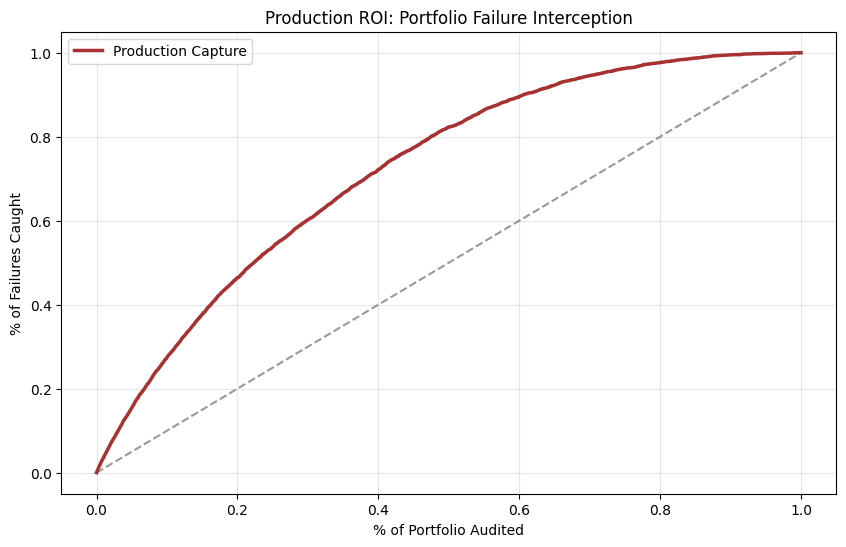

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc_val = roc_auc_score(y_train, y_prob_train)
pr_auc_val = average_precision_score(y_train, y_prob_train)

print(f"Production ROC-AUC: {auc_val:.4f}")
print(f"Production PR-AUC:  {pr_auc_val:.4f}")

# ROI Plot (Failure Capture)
data_roi = pd.DataFrame({'target': y_train, 'prob': y_prob_train}).sort_values('prob', ascending=False)
data_roi['cum_pop'] = np.arange(1, len(data_roi) + 1) / len(data_roi)
data_roi['cum_gain'] = data_roi['target'].cumsum() / data_roi['target'].sum()

plt.figure(figsize=(10, 6))
plt.plot(data_roi['cum_pop'], data_roi['cum_gain'], color='#A83232', lw=2.5, label='Production Capture')
plt.plot([0, 1], [0, 1], '--', color='#555555', alpha=0.6)
plt.title("Production ROI: Portfolio Failure Interception")
plt.xlabel("% of Portfolio Audited")
plt.ylabel("% of Failures Caught")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### <REF:PROD_UI_VERIFY>
> #### **11. Production UI Verification: Vibrant Visualization Snapshots**

Generates high-fidelity snapshots of UI components (Gauge, Impact Bar, Treemap). This serves as a final validation to ensure scoring math and clinical pillar logic are perfectly synchronized before deployment.

In [12]:
# <REF:UI_VIS_CODE>
Trial_Example = 1205

print(f"\n>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID {Trial_Example}...")


import plotly.graph_objects as go
import pandas as pd
import numpy as np
import re
import textwrap

# ==============================================================================
# 0. UNIFIED STYLE CONFIGURATION (UPDATED TO VIBRANT PALETTE)
# ==============================================================================
STYLE_CONFIG = {
    # FONTS
    "font_family": "Arial",
    "font_size_header": 16,
    "font_size_body": 14,
    "font_color": "#1f2a38", # Dark Navy/Black

    # COLOR PALETTE (Vibrant Professional - Matches Data Science Graph)
    # We converted the HEX codes from the previous step into RGB tuples here.
    "colors": {
        # High Risk (Fail Deep): #A83232
        "red_deep":   (168, 50, 50),

        # Watchlist (Fail Soft): #F0A3A3
        "red_soft":   (240, 163, 163),

        # Center Neutral
        "grey_warm":  (242, 244, 248),

        # Good (Succ Soft): #9ACBE8
        "blue_soft":  (154, 203, 232),

        # Robust (Succ Deep): #1C5699
        "blue_deep":  (28, 86, 153),

        # Static Colors
        "therapeutic_grey": "#CFD8DC",
        "separator_white": "white"
    }
}

def get_rgb_str(rgb_tuple):
    """Converts (r,g,b) tuple to 'rgb(r,g,b)' string."""
    return f"rgb({rgb_tuple[0]},{rgb_tuple[1]},{rgb_tuple[2]})"

def interpolate_color(c1, c2, ratio):
    """Linearly interpolates between two RGB tuples."""
    r = int(c1[0] + (c2[0] - c1[0]) * ratio)
    g = int(c1[1] + (c2[1] - c1[1]) * ratio)
    b = int(c1[2] + (c2[2] - c1[2]) * ratio)
    return (r, g, b)

def get_contrast_color(r, g, b):
    """Utility for contrast text (White vs Black)."""
    rs, gs, bs = r / 255.0, g / 255.0, b / 255.0
    L = 0.2126 * rs + 0.7152 * gs + 0.0722 * bs
    return "#000000" if L > 0.6 else "#FFFFFF"

def mix_white(rgb, factor=0.7):
    """Mixes a color with white to create a lighter 'pastel' version."""
    r, g, b = rgb
    new_r = int(r + (255 - r) * factor)
    new_g = int(g + (255 - g) * factor)
    new_b = int(b + (255 - b) * factor)
    return (new_r, new_g, new_b)

def fmt_header(text, value, txt_color="black", split=False):
    """Standardized Header Format."""
    if split:
        label = f"{text}<br>({value:+.1f}%)"
    else:
        label = f"{text} ({value:+.1f}%)"
    return (
        f"<span style='font-size:14px; font-weight:bold; color:{txt_color}'>"
        f"{label}"
        f"</span>"
    )

# ==============================================================================
# 1. GAUGE CHART
# ==============================================================================
print("\n=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===")

def plot_risk_gauge(score_val):
    steps = []
    n_slices = 100
    c = STYLE_CONFIG["colors"]

    for i in range(n_slices):
        v_start, v_end = i, i + 1
        if i < 25:
            color = interpolate_color(c["red_deep"], c["red_soft"], i / 25.0)
        elif i < 50:
            color = interpolate_color(c["red_soft"], c["grey_warm"], (i - 25) / 25.0)
        elif i < 75:
            color = interpolate_color(c["grey_warm"], c["blue_soft"], (i - 50) / 25.0)
        else:
            color = interpolate_color(c["blue_soft"], c["blue_deep"], (i - 75) / 25.0)
        steps.append({'range': [v_start, v_end], 'color': get_rgb_str(color)})

    for sep in [25, 50, 75]:
        steps.append({'range': [sep - 0.5, sep + 0.5], 'color': 'white'})

    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=score_val,
        number={
            "suffix": "",
            "valueformat": ".1f",
            "font": {"size": 52, "color": STYLE_CONFIG["font_color"],
                     "family": STYLE_CONFIG["font_family"], "weight": "bold"}
        },
        domain={"x": [0, 1], "y": [0, 1]},
        gauge={
            "axis": {
                "range": [0, 100],
                "tickmode": "array",
                "tickvals": [0, 25, 50, 75, 100],
                "ticktext": ["0", "25", "50", "75", "100"],
                "ticklen": 0, "tickwidth": 0, "tickcolor": "white",
                "tickfont": {"size": STYLE_CONFIG["font_size_body"],
                             "color": "#555555",
                             "family": STYLE_CONFIG["font_family"], "weight": "bold"},
            },
            "bar": {"color": "rgba(0,0,0,0)"},
            "bgcolor": "white",
            "borderwidth": 0,
            "steps": steps,
            "threshold": {
                "line": {"color": STYLE_CONFIG["font_color"], "width": 5},
                "thickness": 0.75,
                "value": score_val
            },
        },
    ))
    fig.update_layout(
        margin=dict(l=35, r=35, t=40, b=10),
        paper_bgcolor="white",
        font={"family": STYLE_CONFIG["font_family"], "color": "#333333"},
        height=220,
        hovermode=False
    )
    fig.update_traces(gauge_bar_thickness=0.75)
    return fig

# ==============================================================================
# 2. IMPACT BAR CHART (VIBRANT EDGES + UNIFORM GRADIENT)
# ==============================================================================
print("\n=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===")

def get_pillar_impacts(df_scores, trial_index):
    # Standard data extraction
    meta_cols = ['Clinical_Score', 'Therapeutic_Area', 'Phase', 'Internal_Score_Raw', 'Zone', 'CALIBRATION_OFFSET']
    pillar_cols = [c for c in df_scores.columns if c not in meta_cols]
    row = df_scores.loc[trial_index, pillar_cols].copy()

    # Redundant sync removed (already handled in scorecard generation)

    df_impact = pd.DataFrame({'Pillar': row.index, 'Impact': row.values})
    df_impact['Pillar_Clean'] = df_impact['Pillar'].apply(lambda x: x.split('. ', 1)[1] if '. ' in x else x)
    df_impact['Label'] = df_impact['Impact'].apply(lambda x: f"{x:+.1f}%")

    # Sort by impact for the plot
    df_impact = df_impact.sort_values(by='Impact', ascending=True)
    return df_impact

def plot_impact_bar(df_impact, trial_id, score):
    max_val = df_impact['Impact'].abs().max()
    limit = max_val * 1.35

    # --- CONFIGURATION ---
    SLICE_STEP = 0.08      # Fixed width slices for uniform look
    BAR_WIDTH = 0.75       # Bar Thickness

    # TUNING KNOB 1: SATURATION POINT
    # Lower = Reaches "Deep" color faster (Darker Edges)
    # 4.0 means any bar > 4% will have a fully dark tip.
    GLOBAL_MAX_SCALE = 4.0

    # Colors
    c = STYLE_CONFIG["colors"]
    center_grey = c["grey_warm"]

    # Helper
    def hex_to_rgb(hex_str):
        hex_str = hex_str.lstrip('#')
        return tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4))

    fig = go.Figure()

    # Calculate how many steps we need
    total_steps = int(np.ceil(max_val / SLICE_STEP))

    for i in range(total_steps):
        current_abs_pos = i * SLICE_STEP

        slice_widths = []
        slice_colors = []
        slice_texts = []

        for idx, val in enumerate(df_impact['Impact']):
            abs_val = abs(val)
            pillar_name = df_impact['Pillar'].iloc[idx]

            # 1. Calculate Width
            if current_abs_pos >= abs_val:
                w = 0
                is_tip = False
            elif current_abs_pos + SLICE_STEP > abs_val:
                w = abs_val - current_abs_pos
                is_tip = True
            else:
                w = SLICE_STEP
                is_tip = False

            if val < 0: w = -w
            slice_widths.append(w)

            # 2. Label
            if is_tip:
                slice_texts.append(df_impact['Label'].iloc[idx])
            else:
                slice_texts.append(None)

            # 3. Calculate Color
            color_pos = current_abs_pos + (abs(w) / 2)

            # Special Case: Therapeutic Area
            if "Therapeutic" in pillar_name:
                hex_val = STYLE_CONFIG["colors"]["therapeutic_grey"]
                rgb = hex_to_rgb(hex_val)
                slice_colors.append(f"rgb({rgb[0]},{rgb[1]},{rgb[2]})")
                continue

            # --- INTENSITY LOGIC ---
            ratio = min(color_pos / GLOBAL_MAX_SCALE, 1.0)

            # TUNING KNOB 2: ACCELERATION
            # 0.5 makes the color ramp up stronger in the middle
            ratio = ratio ** 0.5

            if val >= 0:
                # POSITIVE
                if ratio < 0.5:
                    local_ratio = ratio * 2
                    final_rgb = interpolate_color(center_grey, c["blue_soft"], local_ratio)
                else:
                    local_ratio = (ratio - 0.5) * 2
                    final_rgb = interpolate_color(c["blue_soft"], c["blue_deep"], local_ratio)
            else:
                # NEGATIVE
                if ratio < 0.5:
                    local_ratio = ratio * 2
                    final_rgb = interpolate_color(center_grey, c["red_soft"], local_ratio)
                else:
                    local_ratio = (ratio - 0.5) * 2
                    final_rgb = interpolate_color(c["red_soft"], c["red_deep"], local_ratio)

            slice_colors.append(f"rgb({final_rgb[0]},{final_rgb[1]},{final_rgb[2]})")

        # Add Trace
        fig.add_trace(go.Bar(
            y=df_impact['Pillar_Clean'],
            x=slice_widths,
            orientation='h',
            width=BAR_WIDTH,
            marker=dict(
                color=slice_colors,
                line=dict(width=0)
            ),
            text=slice_texts,
            textposition='outside',
            textfont=dict(size=STYLE_CONFIG["font_size_body"], color="black", family=STYLE_CONFIG["font_family"]),
            hoverinfo='skip',
            showlegend=False
        ))

    # Vertical Line at 0
    fig.add_vline(x=0, line_width=1, line_color="#333333")

    fig.update_layout(
        barmode='relative',
        xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, range=[-limit, limit]),
        yaxis=dict(showticklabels=True, tickfont=dict(size=STYLE_CONFIG["font_size_body"], color="black", family=STYLE_CONFIG["font_family"]), automargin=True),
        margin=dict(l=10, r=10, t=50, b=10),
        plot_bgcolor="white", paper_bgcolor="white", height=300, showlegend=False
    )
    return fig
# ==============================================================================
# 3. TREEMAP
# ==============================================================================
print("\n=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===")

def plot_smart_treemap(shap_values, feature_names, trial_index, taxonomy, gain_factor, df_scores):
    try:
        pos_idx = df_scores.index.get_loc(trial_index)
        row_shap = shap_values[pos_idx]
        calib_credit = df_scores.loc[trial_index, 'CALIBRATION_OFFSET']
    except: return go.Figure()

    nodes = {}
    node_sums = {"ALL_DRIVERS": 0.0, "OPERATIONAL_DRIVERS": 0.0, "THERAPEUTIC_CONTEXT": 0.0}
    c = STYLE_CONFIG["colors"]
    leaf_data = []

    for pillar_raw, topics in taxonomy.items():
        pillar_clean = pillar_raw.split('. ', 1)[1] if '. ' in pillar_raw else pillar_raw
        is_therapeutic = "Therapeutic" in pillar_raw
        parent_id = "THERAPEUTIC_CONTEXT" if is_therapeutic else f"PILLAR_{pillar_clean}"
        if parent_id not in node_sums: node_sums[parent_id] = 0.0

        for subtopic, details in topics.items():
            prefixes = details['features']
            impact = 0.0
            shap_prefixes = [p for p in prefixes if p != "CALIBRATION_OFFSET"]
            if shap_prefixes:
                total_shap = sum(row_shap[i] for i, f in enumerate(feature_names) if any(f.startswith(p) for p in shap_prefixes))
                impact += (total_shap * gain_factor * -1)
            if "CALIBRATION_OFFSET" in prefixes:
                impact += calib_credit

            narrative = details['pos_impact'] if impact >= 0 else details['neg_impact']
            ratio = min(abs(impact) / 8.0, 1.0)
            ratio = max(0.2, ratio)

            if is_therapeutic:
                r, g, b = (207, 216, 220)
                txt_color = "black"
            elif impact >= 0:
                r, g, b = interpolate_color(c["blue_soft"], c["blue_deep"], ratio)
                txt_color = "white"
            else:
                r, g, b = interpolate_color(c["red_soft"], c["red_deep"], ratio)
                txt_color = "white"

            bg_hex = get_rgb_str((r,g,b))
            wrapped_narrative = '<br>'.join(textwrap.wrap(narrative, width=30))
            label_html = (
                f"<span style='font-size:15px; font-weight:bold; color:{txt_color}'>{subtopic}</span>"
                f"<br><span style='font-size:14px; color:{txt_color}'>{impact:+.1f}%</span>"
                f"<br><br><span style='font-size:13px; font-style:normal; color:{txt_color}'>{wrapped_narrative}</span>"
            )

            leaf_id = f"{parent_id}_{subtopic}"
            node_sums[leaf_id] = impact
            node_sums[parent_id] += impact
            node_sums["ALL_DRIVERS"] += impact
            if not is_therapeutic: node_sums["OPERATIONAL_DRIVERS"] += impact

            leaf_data.append({"id": leaf_id, "parent": parent_id, "label": label_html, "color": bg_hex, "value": abs(impact)})

    def get_header_color(val, is_grey=False):
        if is_grey: return "#ECEFF1"
        ratio = min(abs(val) / 8.0, 1.0)
        if val >= 0:
            base_rgb = interpolate_color(c["blue_soft"], c["blue_deep"], ratio)
        else:
            base_rgb = interpolate_color(c["red_soft"], c["red_deep"], ratio)
        pastel_rgb = mix_white(base_rgb, factor=0.7)
        return get_rgb_str(pastel_rgb)

    for pillar_raw in taxonomy.keys():
        if "Therapeutic" not in pillar_raw:
            p_clean = pillar_raw.split('. ', 1)[1] if '. ' in pillar_raw else pillar_raw
            p_id = f"PILLAR_{p_clean}"
            if p_id in node_sums:
                val = node_sums[p_id]
                nodes[p_id] = {"parent": "OPERATIONAL_DRIVERS", "label": fmt_header(p_clean.upper(), val, txt_color="black"), "color": get_header_color(val), "value": 0}

    ther_val = node_sums["THERAPEUTIC_CONTEXT"]
    nodes["THERAPEUTIC_CONTEXT"] = {"parent": "ALL_DRIVERS", "label": fmt_header("THERAPEUTIC CONTEXT", ther_val, txt_color="black"), "color": "#ECEFF1", "value": 0}

    ops_val = node_sums["OPERATIONAL_DRIVERS"]
    nodes["OPERATIONAL_DRIVERS"] = {"parent": "ALL_DRIVERS", "label": fmt_header("OPERATIONAL DRIVERS", ops_val, txt_color="black"), "color": get_header_color(ops_val), "value": 0}

    root_val = node_sums["ALL_DRIVERS"]
    nodes["ALL_DRIVERS"] = {"parent": "", "label": fmt_header("ALL DRIVERS", root_val, txt_color="black"), "color": "#FFFFFF", "value": 0}

    for item in leaf_data:
        nodes[item['id']] = {"parent": item['parent'], "label": item['label'], "color": item['color'], "value": item['value']}

    ids = list(nodes.keys())
    fig = go.Figure(go.Treemap(
        ids=ids,
        labels=[nodes[k]['label'] for k in ids],
        parents=[nodes[k]['parent'] for k in ids],
        values=[nodes[k]['value'] for k in ids],
        marker=dict(colors=[nodes[k]['color'] for k in ids], line=dict(width=1, color='white')),
        textinfo="label", textposition="top left", tiling=dict(packing="squarify"), hoverinfo="skip",
        pathbar=dict(visible=True, thickness=30, textfont=dict(family="Arial", size=11))
    ))
    fig.update_layout(margin=dict(t=34, l=15, r=15, b=15), height=600, font=dict(family="Arial"), paper_bgcolor='white', hovermode=False)
    return fig

# ==============================================================================
# 4. EXECUTION (Synced with Production Dataset)
# ==============================================================================
target_idx = df_scores.index[Trial_Example]
score_val = df_scores.loc[target_idx, 'Clinical_Score']
# Display Production Metadata
# Print Clinical Metadata from Production DF
print(f"NCT ID:    {df.loc[target_idx, 'nct_id']}")
print(f"Title:     {df.loc[target_idx, 'brief_title']}")
print(f"Area:      {df.loc[target_idx, 'therapeutic_area']}")
outcome_str = "Failure (1)" if df.loc[target_idx, "target"]==1 else "Success (0)"
print(f"Outcome:   {outcome_str}")


fig_gauge = plot_risk_gauge(score_val)
fig_gauge.show()

# 2. Bar Chart
df_impact_test = get_pillar_impacts(df_scores, target_idx)
fig_bar = plot_impact_bar(df_impact_test, target_idx, score_val)
fig_bar.show()

# 3. Treemap
fig_tree = plot_smart_treemap(shap_values, feature_names, target_idx, RISK_TAXONOMY, GAIN_FACTOR, df_scores)
fig_tree.show()

# <REF:/UI_VIS_CODE>


>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID 1205...

=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===

=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===

=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===
NCT ID:    NCT04932512
Title:     A Study to Assess the Safety, Efficacy, and Pharmacokinetics of Multiple Doses of ION224
Area:      Gastrointestinal
Outcome:   Success (0)


#### <REF:PROD_EXPORT>
> #### **12. Production Artifact Export: Deployment Serialization**

Serializes the 'Brain' (`model_prod_01.joblib`), 'Scale' (`thresholds_01.json`), and 'Taxonomy'. This ensures the Streamlit application operates on the exact same mathematical foundation as the validation environment.

In [13]:
# --- STEP 12: CORE ARTIFACT SERIALIZATION ---
import joblib
import json
import os

# 1. Save Brain (XGBoost Model Pipeline)
joblib.dump(model, os.path.join(MODELS_PATH, 'model_prod_01.joblib'))

# 2. Save Scale (TA-specific Threshold Logits)
with open(os.path.join(MODELS_PATH, 'thresholds_01.json'), 'w') as f:
    json.dump(final_threshold_logits, f)

# 3. Save Logic (Taxonomy)
with open(os.path.join(MODELS_PATH, 'taxonomy_01.json'), 'w') as f:
    json.dump(RISK_TAXONOMY, f)

print("[SUCCESS] Core production artifacts (Brain, Scale, Logic) serialized to /models")

[SUCCESS] Core production artifacts (Brain, Scale, Logic) serialized to /models


#### <REF:PROD_CALIB_AUDIT>
> #### **13. Granular Boundary Verification: Therapeutic Area Deep Dive**

A detailed audit of TA-specific thresholds. We verify that each boundary is anchored by sufficient contemporary data, comparing 'Full Portfolio' vs. 'Modern Era' (2021-2022) failure densities.

In [14]:
# --- STEP 13: CALIBRATION AUDIT ---
from sklearn.metrics import precision_score, recall_score, roc_auc_score

print('>>> STEP 13: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...')
print('[SCOPE] Full Columns:   2009-2022 Portfolio Baseline')
print('[SCOPE] Recent Columns: 2021-2022 Modern Era Audit (In-Sample)')

def get_ta_stats(df_eval, probs, thresholds_map, g_thresh):
    results = []
    total_y = df_eval['target']
    # Corrected: using thresholds_map (matching parameter name)
    total_p = (probs >= df_eval['therapeutic_area'].map(thresholds_map).fillna(g_thresh)).astype(int)
    results.append({
        'TA': 'TOTAL (Strategy)',
        'N': len(df_eval),
        'Fail%': f'{total_y.mean():.1%}',
        'AUC': f'{roc_auc_score(total_y, probs):.3f}',
        'Prec': f'{precision_score(total_y, total_p, zero_division=0):.1%}',
        'Rec': f'{recall_score(total_y, total_p, zero_division=0):.1%}',
        'Thresh': f'{g_thresh:.4f}'
    })

    for ta in sorted(df_eval['therapeutic_area'].unique()):
        mask = df_eval['therapeutic_area'] == ta
        y_ta = df_eval.loc[mask, 'target']
        if len(y_ta) == 0 or y_ta.nunique() < 2:
            auc = 'N/A'
        else:
            auc = f'{roc_auc_score(y_ta, probs[mask]):.3f}'

        t_ta = thresholds_map.get(ta, g_thresh)
        p_ta = (probs[mask] >= t_ta).astype(int)

        results.append({
            'TA': ta,
            'N': len(y_ta),
            'Fail%': f'{y_ta.mean():.1%}',
            'AUC': auc,
            'Prec': f'{precision_score(y_ta, p_ta, zero_division=0):.1%}',
            'Rec': f'{recall_score(y_ta, p_ta, zero_division=0):.1%}',
            'Thresh': f'{t_ta:.4f}'
        })
    return pd.DataFrame(results)

mask_full = df['start_year'].between(2009, 2022)
mask_rec  = df['start_year'] >= 2021

stats_full = get_ta_stats(df[mask_full], y_prob_train[mask_full], final_thresholds, global_thresh)
stats_rec  = get_ta_stats(df[mask_rec], y_prob_train[mask_rec], final_thresholds, global_thresh)

summary = stats_full[['TA', 'N', 'Fail%', 'AUC', 'Prec', 'Rec']].merge(
    stats_rec[['TA', 'N', 'Fail%', 'AUC', 'Prec', 'Rec', 'Thresh']],
    on='TA', suffixes=(' Full', ' Rec')
)

# Sorting logic: TOTAL first, then by Full N descending
total_row = summary[summary['TA'] == 'TOTAL (Strategy)']
ta_rows = summary[summary['TA'] != 'TOTAL (Strategy)'].copy()
ta_rows['N Full Int'] = ta_rows['N Full'].astype(int)
ta_rows = ta_rows.sort_values('N Full Int', ascending=False).drop(columns=['N Full Int'])
summary_sorted = pd.concat([total_row, ta_rows])

print('\n=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===')
header = "TA                   | F.N    | F.F%    | F.AUC  | F.Pr   | F.Re   | R.N    | R.F%    | R.AUC  | R.Pr   | R.Re   | Thresh"
print(header)
print('-' * len(header))
for _, row in summary_sorted.iterrows():
    line = f"{row['TA']:<20} | {row['N Full']:<6} | {row['Fail% Full']:<7} | {row['AUC Full']:<6} | {row['Prec Full']:<6} | {row['Rec Full']:<6} | {row['N Rec']:<6} | {row['Fail% Rec']:<7} | {row['AUC Rec']:<6} | {row['Prec Rec']:<6} | {row['Rec Rec']:<6} | {row['Thresh']}"
    print(line)

print('\n>>> RENDERING TOP 6 THERAPEUTIC AREA DEEP DIVES (RESTORED FIDELITY) ...')

>>> STEP 13: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...
[SCOPE] Full Columns:   2009-2022 Portfolio Baseline
[SCOPE] Recent Columns: 2021-2022 Modern Era Audit (In-Sample)

=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===
TA                   | F.N    | F.F%    | F.AUC  | F.Pr   | F.Re   | R.N    | R.F%    | R.AUC  | R.Pr   | R.Re   | Thresh
-------------------------------------------------------------------------------------------------------------------------
TOTAL (Strategy)     | 24592  | 20.0%   | 0.779  | 38.9%  | 72.6%  | 2988   | 31.1%   | 0.814  | 50.9%  | 82.1%  | 0.4990
Oncology             | 5030   | 31.5%   | 0.736  | 43.7%  | 81.9%  | 564    | 55.7%   | 0.741  | 65.3%  | 87.6%  | 0.6101
Infections           | 3417   | 14.8%   | 0.829  | 38.3%  | 67.9%  | 571    | 26.4%   | 0.837  | 49.0%  | 82.8%  | 0.4834
Neurology            | 2455   | 22.1%   | 0.748  | 41.4%  | 62.7%  | 281    | 31.7%   | 0.765  | 53.0%  | 68.5%  | 0.5658
Metabolic            | 1637   | 11.0%

#### <REF:PROD_PREDICT_GEN>
> #### **14. Predict Universe Generation: Portfolio Ingestion**

This step initializes the data for the **entire portfolio** (44,000+ trials). 
*   **Expansion**: We look at a wider window (2005–2026) than the training set.
*   **Persistence**: We check if a feature store (`project_data_predict.csv`) already exists to skip the 20-minute engineering phase.
*   **Consistency**: We use `ClinicalTrialLoaderPredict` to ensure features for 'Ongoing' trials are built exactly like the 'Historical' ones.

In [15]:
# --- STEP 14: PREDICT UNIVERSE GENERATION ---
from src.prep.data_loader_predict_02 import ClinicalTrialLoaderPredict

PREDICT_DATA_PATH = DATA_PATH / "project_data_predict.csv"

# 1. Load or Generate Predict Universe
# We check for a pre-engineered feature store to save processing time (approx 20 mins)
if PREDICT_DATA_PATH.exists():
    print(f">>> Loading pre-engineered Predict Universe from {PREDICT_DATA_PATH}...")
    df_universe = pd.read_csv(PREDICT_DATA_PATH, low_memory=False)
else:
    print(">>> Initializing full Predict Ingestion (Expanded Horizon 2005-2026)...")
    predict_loader = ClinicalTrialLoaderPredict(str(DATA_PATH))
    df_universe = predict_loader.load_and_clean()
    df_universe = predict_loader.add_features(df_universe)

    # Save for future speed
    predict_loader.save(df_universe, 'project_data_predict.csv')

# 2. Reset Index for Alignment
# This ensures that SHAP value rows match DataFrame rows perfectly
df_universe = df_universe.reset_index(drop=True)

# 3. Segment Analysis
n_hist = len(df_universe[df_universe.trial_segment == 'HISTORICAL'])
n_ongo = len(df_universe[df_universe.trial_segment == 'ONGOING'])

print(f"\n>>> Engineered {len(df_universe):,} trials for the Predict Universe.")
print(f"    - Historical (Labeled Results): {n_hist:,}")
print(f"    - Ongoing (Pending Predictions): {n_ongo:,}")

>>> Initializing full Predict Ingestion (Expanded Horizon 2005-2026)...
>>> 1. Loading Studies & Applying Filters (Predict Universe v02)...
    [Filter] Kept 126474 Industry-led trials.
    [Sanitizer] Dropping 171 trials terminated due to COVID/Logistics.
    Full Universe: 44386 trials (Phase 2/3 focus, 2005-2026).
>>> 2. Engineering Features (Dual-Path Implementation v02)...
    -> Grouping Phases...
    -> Engineering Clinical Setting...
    -> Engineering Comparator Architecture...
    -> Engineering Protocol Duration...
    -> Engineering Sponsor Tiers...
    -> Engineering Protocol Complexity...
    -> Attaching Medical Hierarchy...
    -> Adding UI-friendly text fields...
    -> Engineering NLP Text Pillars...
    -> Engineering Agent Type...
    -> Engineering Smart Competition...
    -> Engineering Smart Patterns...
    -> Engineering Gated Protocol Features...
    -> Attaching BioBERT Embeddings...
    -> Attaching P-Values...
    -> Finalizing Data Types...
>>> Saved 44386 

#### <REF:PROD_SERIALIZE_LOCKED>
> #### **15. Scoring & Explainability: The UI Brain**

We now apply our trained production model to the full universe.
1.  **Transformation**: Raw data is converted into 548 model features.
2.  **SHAP drivers**: We calculate the 'Risk/Impact' for every single trial.
3.  **Scoring**: We apply the **Sync Protocol** to map model outputs to the 0–100 Success Score.
4.  **ID-Locking**: SHAP values are saved in a dictionary mapping NCT IDs to impacts, ensuring the UI always displays the correct drivers for a selected trial.

In [16]:
# --- STEP 15.1: SHAP CALCULATION (PORTFOLIO-WIDE) ---
print(">>> Preparing Prediction Matrix & Calculating SHAP drivers...")

# A. Prepare the feature matrix (excluding metadata and raw text)
X_universe = df_universe.drop(columns=cols_to_drop, errors='ignore')

# B. Run Preprocessing Pipeline
# This converts categories/numbers into the final model-ready features (548 dims)
X_universe_trans = model.named_steps['prep'].transform(X_universe)

# C. Calculate SHAP Values
# This attributes the prediction to every single input feature
shap_values_universe = explainer.shap_values(X_universe_trans)

print(f"    [DONE] Calculated SHAP for {shap_values_universe.shape[0]} trials.")

>>> Preparing Prediction Matrix & Calculating SHAP drivers...
    [DONE] Calculated SHAP for 44386 trials.


In [17]:
# --- STEP 15.2: SCORING ENGINE (THE SYNC PROTOCOL) ---
print(">>> Generating Success Scores using Therapeutic Area (TA) calibration...")

# D. Apply the Clinical Success Score calculation
# This uses the 'Sync Protocol': Final Score = 50 + Sum(Pillar Impacts)
df_universe_scores = generate_production_scorecard(
    X_universe, shap_values_universe, feature_names, RISK_TAXONOMY,
    base_value=model_base_value,
    thresholds_logit_map=final_threshold_logits,
    global_thresh_logit=global_logit
)

# Merge back the scores and zones
df_universe = df_universe.merge(df_universe_scores[['Clinical_Score', 'Zone']], left_index=True, right_index=True)

>>> Generating Success Scores using Therapeutic Area (TA) calibration...


In [18]:
# --- STEP 15.3: SHAP REGISTRY EXPORT ---
# Create an ID-locked dictionary: {nct_id: shap_array}
# This allows the UI to fetch the 548 feature impacts instantly using the trial ID
shap_lookup = dict(zip(df_universe['nct_id'], shap_values_universe))

# Save the artifact (Joblib is used for binary efficiency)
joblib.dump(shap_lookup, MODELS_PATH / "shap_values_01.joblib")
print(f"[SUCCESS] SHAP Registry locked with {len(shap_lookup):,} NCT IDs.")

[SUCCESS] SHAP Registry locked with 44,386 NCT IDs.


#### <REF:PROD_FORENSIC_AUDIT>
> #### **16. Forensic Math Audit: Strategic Recoupling Verification**

**Verification Logic**: We ensure that the `Clinical_Score` saved in our database is mathematically identical to the one derived from the raw SHAP values and model intercept. If this audit passes, it guarantees that the **Gauge** and the **Risk Bars** in the UI will always be in perfect sync.

In [19]:
# --- STEP 16: FORENSIC MATH AUDIT ---
print(">>> Verifying Scoring Math (Logit -> Score 100 Transition)...")

# Randomly sample 5 trials across the registry
sample_audit = df_universe.sample(5, random_state=42)
gain = float(GAIN_FACTOR)

print("\n--- Scoring Integrity Audit ---")
for _, row in sample_audit.iterrows():
    nid = row['nct_id']
    ta = row['therapeutic_area']
    csv_score = row['Clinical_Score']

    # 1. Fetch threshold for this TA
    ta_t_logit = final_threshold_logits.get(ta, global_logit)

    # 2. Reconstruct Model Logit (Intercept + Sum of SHAP)
    model_logit = float(model_base_value) + np.sum(shap_lookup[nid])

    # 3. Calculate Score: 50 + (Threshold - Prediction) * Gain
    calculated_score = np.clip(50 + (ta_t_logit - model_logit) * gain, 1, 99)

    diff = abs(csv_score - calculated_score)
    status = "PASS" if diff < 0.01 else "FAIL"

    print(f"[{status}] {nid:<12} | TA: {ta:<12} | CSV: {csv_score:.2f} | Calc: {calculated_score:.2f}")

>>> Verifying Scoring Math (Logit -> Score 100 Transition)...

--- Scoring Integrity Audit ---
[PASS] NCT04102241  | TA: Dermatology  | CSV: 65.27 | Calc: 65.27
[PASS] NCT07059650  | TA: Oncology     | CSV: 47.26 | Calc: 47.26
[PASS] NCT02276482  | TA: Infections   | CSV: 65.80 | Calc: 65.80
[PASS] NCT00550875  | TA: Respiratory  | CSV: 60.33 | Calc: 60.33
[PASS] NCT00655889  | TA: Unclassified | CSV: 74.12 | Calc: 74.12


#### <REF:PROD_FEATURE_AUDIT>
> #### **17. Fidelity Audit & Transparency Mapping**

We implement a **'Glass Box'** approach. Every prediction is audited for 'Imputation Density'. 
*   **HIGH Fidelity**: Complete protocol data provided.
*   **LOW Fidelity**: Missing key documents (Title/Summary) or structural data.
Finally, we restore human-readable `NaN` (blanks) for the UI, ensuring the dashboard doesn't show internal "UNKNOWN" placeholders.

In [20]:
# --- STEP 17.1: PROTOCOL FIDELITY AUDIT ---
# We audit every trial to see if model inputs are "Sparse" or "Densely Populated"
print(">>> Auditing Protocol Fidelity (21 Checkpoints)...")

# Check for missing numeric/structural data
missing_matrix = pd.DataFrame(index=df_universe.index)
for col in ['number_of_arms', 'enrollment', 'number_of_facilities']:
    missing_matrix[col] = df_universe[col].isna()

# Audit Text Quality (Are pillars empty or too short?)
missing_matrix['scientific_signal'] = (
    df_universe['txt_scientific_essence'].str.contains('No title provided|No summary provided', na=True) |
    (df_universe['txt_scientific_essence'].str.len() < 250)
)
missing_matrix['criteria_signal'] = (
    df_universe['txt_criteria'].str.contains('No criteria provided', na=True) |
    (df_universe['txt_criteria'].str.len() < 100)
)

# Label based on missing density
imputed_count = missing_matrix.sum(axis=1)
df_universe['prediction_quality'] = 'HIGH'
df_universe.loc[imputed_count >= 3, 'prediction_quality'] = 'MEDIUM (INCOMPLETE DATA)'
df_universe.loc[imputed_count >= 5, 'prediction_quality'] = 'LOW (MINIMAL DATA)'
df_universe.loc[missing_matrix['scientific_signal'] | missing_matrix['criteria_signal'], 'prediction_quality'] = 'LOW (LIMITED DOCUMENTATION)'

>>> Auditing Protocol Fidelity (21 Checkpoints)...


In [21]:
# --- STEP 17.2: DATA TRANSPARENCY (RAW AUTHORITATIVE PATH) ---
print(">>> Restoring UI transparency (Mapping raw AACT strings for display)...")

# 1. Mapping: {UI Display Name: Column name in df_universe}
# We prioritize 'raw_' columns for categorical/structural fields to ensure NaN restitution.
column_mapping = {
    'nct_id': 'nct_id',
    'raw_nct_id': 'raw_nct_id',
    'brief_title': 'brief_title',
    'official_title': 'official_title',
    'overall_status': 'overall_status',
    'why_stopped': 'why_stopped',
    'raw_why_stopped': 'raw_why_stopped',
    'trial_segment': 'trial_segment',
    'start_year': 'start_year',
    'start_date': 'start_date',
    'raw_start_date': 'raw_start_date',
    'lead_sponsor': 'raw_lead_sponsor',
    'Clinical_Score': 'Clinical_Score',
    'Zone': 'Zone',
    'prediction_quality': 'prediction_quality',
    'number_of_arms': 'raw_number_of_arms',
    'duration_months': 'duration_months',
    'enrollment': 'raw_enrollment',
    'number_of_facilities': 'raw_number_of_facilities',
    'phase': 'raw_phase',
    'masking': 'raw_masking',
    'allocation': 'raw_allocation',
    'primary_purpose': 'raw_primary_purpose',
    'intervention_model': 'raw_intervention_model',
    'therapeutic_area': 'therapeutic_area',
    'raw_therapeutic_area': 'raw_therapeutic_area',
    'therapeutic_subgroup_name': 'therapeutic_subgroup_name',
    'raw_therapeutic_subgroup_name': 'raw_therapeutic_subgroup_name',
    'agent_category': 'agent_category',
    'raw_agent_category': 'raw_agent_category',
    'sponsor_tier': 'sponsor_tier',
    'raw_sponsor_clean': 'raw_sponsor_clean',
    'has_dmc': 'has_dmc',
    'is_acute': 'is_acute',
    'is_refractory': 'is_refractory',
    'is_severe': 'is_severe',
    'is_critical_setting': 'is_critical_setting',
    'is_sick_only': 'is_sick_only',
    'ui_title': 'ui_title',
    'raw_ui_title': 'raw_ui_title',
    'ui_brief_title': 'ui_brief_title',
    'raw_ui_brief_title': 'raw_ui_brief_title',
    'ui_summary': 'ui_summary',
    'raw_ui_summary': 'raw_ui_summary',
    'ui_criteria': 'ui_criteria',
    'raw_ui_criteria': 'raw_ui_criteria',
    'raw_ui_arms_summary': 'raw_ui_arms_summary',
    'raw_ui_arms_group_type': 'raw_ui_arms_group_type',
    'txt_primary_endpoints': 'txt_primary_endpoints',
    'raw_txt_primary_endpoints': 'raw_txt_primary_endpoints',
    'min_p_value': 'min_p_value',
    'raw_min_p_value': 'raw_min_p_value',
    'scientific_success': 'scientific_success',
    'raw_scientific_success': 'raw_scientific_success',
    'gender': 'gender',
    'raw_gender': 'raw_gender',
    'healthy_volunteers': 'healthy_volunteers',
    'raw_healthy_volunteers': 'raw_healthy_volunteers',
    'child': 'child',
    'raw_child': 'raw_child',
    'adult': 'adult',
    'raw_adult': 'raw_adult',
    'older_adult': 'older_adult',
    'raw_older_adult': 'raw_older_adult',
    'raw_minimum_age': 'raw_minimum_age',
    'raw_maximum_age': 'raw_maximum_age'
}

# 2. Construct the Search Registry with Fidelity Audit
missing_cols = [c for c in column_mapping.values() if c not in df_universe.columns]
if missing_cols:
    print(f"[WARN] {len(missing_cols)} columns missing. Creating placeholders.")
    print(f"       Missing: {missing_cols}")

# Create DataFrame with ALL target columns to preserve UI schema
app_search_data = pd.DataFrame(index=df_universe.index)
for ui_name, source_col in column_mapping.items():
    if source_col in df_universe.columns:
        app_search_data[ui_name] = df_universe[source_col]
    else:
        app_search_data[ui_name] = np.nan

# 3. Final Polish: Ensure "literally nothing" for empty fields
# We cast to object to prevent crashes on Categorical columns (like 'Zone')
# and ensure NaNs are replaced by "literally nothing" (empty strings).
app_search_data = app_search_data.astype(object).replace(['nan', 'None', 'N/A', 'NaN', 'none'], np.nan).fillna("")

# 4. Save the Master Registry
SEARCH_DATA_PATH = MODELS_PATH / "app_search_data_01.csv"
app_search_data.to_csv(SEARCH_DATA_PATH, index=False)

print(f"\n[SUCCESS] Registry exported to {SEARCH_DATA_PATH}")
print(f"          - Portfolio size: {len(app_search_data):,} trials")
print(f"          - High Fidelity count: {(app_search_data.prediction_quality=='HIGH').sum():,}")


>>> Restoring UI transparency (Mapping raw AACT strings for display)...

[SUCCESS] Registry exported to /home/delaunan/code/delaunan/clintrialpredict/models/app_search_data_01.csv
          - Portfolio size: 44,386 trials
          - High Fidelity count: 43,232


#### <REF:PROD_DEMO_SYNC>
> #### **17.3 Automated UI Sync: search_registry.csv**

This step generates the **search_registry.csv** which powers the UI dropdown.
It is a curated subset of the master `app_search_data_01.csv` registry.

**Selection Criteria for Demo:**
*   **Status**: Completed or Terminated (No ongoing).
*   **Recency**: Started in **2022 or later**.
*   **Focus**: **Tier 1 Giants** (Roche, UCB, Lonza, Pfizer, BMS, etc.).
*   **Quality**: Only trials where the model score matches the real-world outcome.

In [22]:
# --- STEP 17.3: GENERATING LIVE SEARCH REGISTRY ---
print(">>> Synchronizing search_registry.csv to Frontend...")

# 1. Define Filter Variables
DEMO_START_YEAR = 2022
DEMO_AGENCY = 'INDUSTRY'
DEMO_TIER = 'TIER_1_GIANT'

# 2. Fidelity Check: Model Score must match Actual Target
# Score > 50 means Success (Target 0), Score <= 50 means Failure (Target 1)
is_correct = (
    ((df_universe['Clinical_Score'] > 50.0) & (df_universe['target'] == 0)) |
    ((df_universe['Clinical_Score'] <= 50.0) & (df_universe['target'] == 1))
)

# 3. Filter for the 'Best of' Portfolio
mask_curated = (
    (df_universe['start_year'] >= DEMO_START_YEAR) &
    (df_universe['trial_segment'] == 'HISTORICAL') &
    (df_universe['agency_class'].str.upper() == DEMO_AGENCY) &
    (df_universe['sponsor_tier'] == DEMO_TIER) &
    (is_correct)
)

df_curated = df_universe[mask_curated].copy()

# 4. Construct search_registry (Subset of the Master columns)
search_registry = df_curated[app_search_data.columns].copy()

# 5. AUTOMATED SYNC: Save to frontend
UI_REGISTRY_PATH = project_root / "frontend" / "data" / "search_registry.csv"
search_registry.to_csv(UI_REGISTRY_PATH, index=False)

print(f"[SUCCESS] search_registry.csv updated successfully!")
print(f"          - Origin: Derived from app_search_data_01.csv pool")
print(f"          - Trials: {len(search_registry)} (Industry Tier 1, 2022+)")

>>> Synchronizing search_registry.csv to Frontend...
[SUCCESS] search_registry.csv updated successfully!
          - Origin: Derived from app_search_data_01.csv pool
          - Trials: 414 (Industry Tier 1, 2022+)


In [23]:
# --- STEP 18: FEATURE AUDIT EXPORT (TRANSPOSED) ---
# Purpose: Generate a sample CSV where features are rows and trials are columns for easy manual audit.
print(">>> Generating Transposed Feature Audit Sample (15 trials)...")

# 1. Load the search registry
REGISTRY_PATH = project_root / "frontend" / "data" / "search_registry.csv"
if REGISTRY_PATH.exists():
    df_audit = pd.read_csv(REGISTRY_PATH)

    # 2. Select a representative sample of 15 trials
    # We take the first 15 to keep it deterministic for this audit
    df_sample = df_audit.head(15).copy()

    # 3. Transpose: Features become rows, Trials become columns
    # We use NCT ID as the column header for the transposed view
    if 'nct_id' in df_sample.columns:
        df_sample.set_index('nct_id', inplace=True)

    df_transposed = df_sample.T

    # 4. Save to Models directory
    AUDIT_SAMPLE_PATH = MODELS_PATH / "feature_audit_sample.csv"
    df_transposed.to_csv(AUDIT_SAMPLE_PATH)

    print(f"[SUCCESS] Audit sample exported to {AUDIT_SAMPLE_PATH}")
    print(f"          - Rows (Features): {df_transposed.shape[0]}")
    print(f"          - Cols (Trials):   {df_transposed.shape[1]}")
else:
    print(f"[ERROR] Registry not found at {REGISTRY_PATH}")


>>> Generating Transposed Feature Audit Sample (15 trials)...
[SUCCESS] Audit sample exported to /home/delaunan/code/delaunan/clintrialpredict/models/feature_audit_sample.csv
          - Rows (Features): 65
          - Cols (Trials):   15
